In [9]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [10]:
# Load dataset
spotify_df = pd.read_csv(r"D:\DL Lab 2026\lab02\datasets\spotify_features.csv")
print("Dataset loaded successfully!")
print("Shape:", spotify_df.shape)
print("The dataset:")
spotify_df

Dataset loaded successfully!
Shape: (232725, 18)
The dataset:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


In [11]:
# Understanding the dataset
print("The information about the spotify dataset is: \n",spotify_df.info())
print("\nThe description about the spotify dataset is: \n",spotify_df.describe())
print("\nThe shape of the spotify dataset is: \n",spotify_df.shape)
print("\nThe columns of the spotify dataset are: \n",spotify_df.columns)
print("\nThe datatypes of the columns of the spotify dataset are: \n",spotify_df.dtypes)
print("\nThe memory usage of the spotify dataset is: \n",spotify_df.memory_usage())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [12]:
# Fill missing values with 0
spotify_df.fillna(0, inplace=True)

# Check missing values
print("Missing values in dataset:\n", spotify_df.isnull().sum())

# Select relevant features for popularity prediction
features_spotify = [
    'danceability', 'energy', 'loudness', 'tempo', 
    'acousticness', 'speechiness', 'instrumentalness', 
    'liveness', 'valence', 'duration_ms'
]

# Keep original genre column for possible stratified split and later encoding
genre_col = spotify_df['genre'] if 'genre' in spotify_df.columns else None

# Encode categorical features: 'mode', 'key', and 'genre' (if present)

Missing values in dataset:
 genre               0
artist_name         0
track_name          0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


In [13]:
print("The final dataset is looks like: ")
spotify_df

The final dataset is looks like: 


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.910,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.737,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.131,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.326,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.225,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,38,0.03290,0.785,282447,0.683,0.000880,E,0.2370,-6.944,Minor,0.0337,113.830,4/4,0.969
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,44,0.26200,0.745,222442,0.704,0.000000,A,0.3330,-7.137,Major,0.1460,100.031,4/4,0.489


In [ ]:
target_spotify = 'popularity'

# Transform 'duration_ms' to reduce dominance (log1p) if present
if 'duration_ms' in features_spotify and 'duration_ms' in spotify_df.columns:
    spotify_df['duration_ms'] = np.log1p(spotify_df['duration_ms'])

# Normalize input features
scaler_X = MinMaxScaler()
spotify_df[features_spotify] = scaler_X.fit_transform(spotify_df[features_spotify])

# Normalize target variable (apply log1p transform first to stabilize variance)
scaler_y = MinMaxScaler()
spotify_df[[target_spotify]] = scaler_y.fit_transform(np.log1p(spotify_df[[target_spotify]]))

# Correlation analysis: drop highly correlated features (>0.85) to reduce redundancy
corr_matrix = spotify_df[features_spotify].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
if to_drop:
    print('Dropping highly correlated features:', to_drop)
    for c in to_drop:
        if c in features_spotify:
            features_spotify.remove(c)
    spotify_df.drop(columns=to_drop, inplace=True, errors='ignore')

print("Normalization completed!")
print(spotify_df[features_spotify].head())
print(spotify_df[[target_spotify]].head())

Normalization completed!
   danceability    energy  loudness     tempo  acousticness  speechiness  \
0      0.356292  0.910909  0.900856  0.642704      0.613454     0.032070   
1      0.571934  0.737732  0.834469  0.675801      0.246988     0.068374   
2      0.650252  0.131113  0.686429  0.325182      0.955823     0.014818   
3      0.196438  0.326313  0.716695  0.665238      0.705823     0.018311   
4      0.294067  0.225209  0.557054  0.518516      0.953815     0.024767   

   instrumentalness  liveness  valence  duration_ms  
0          0.000000  0.339614    0.814     0.316771  
1          0.000000  0.142710    0.816     0.371762  
2          0.000000  0.094241    0.368     0.408218  
3          0.000000  0.089697    0.227     0.389421  
4          0.123123  0.194208    0.390     0.285427  
   popularity
0    0.000000
1    0.150190
2    0.300381
3    0.000000
4    0.348732


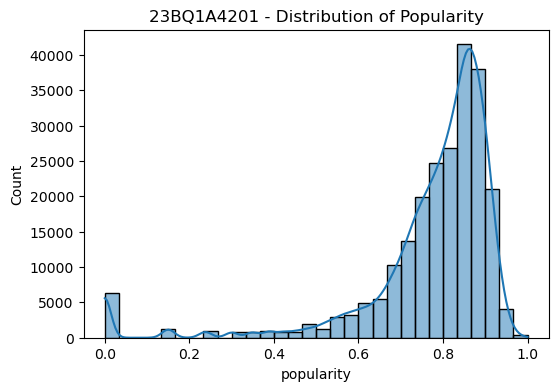

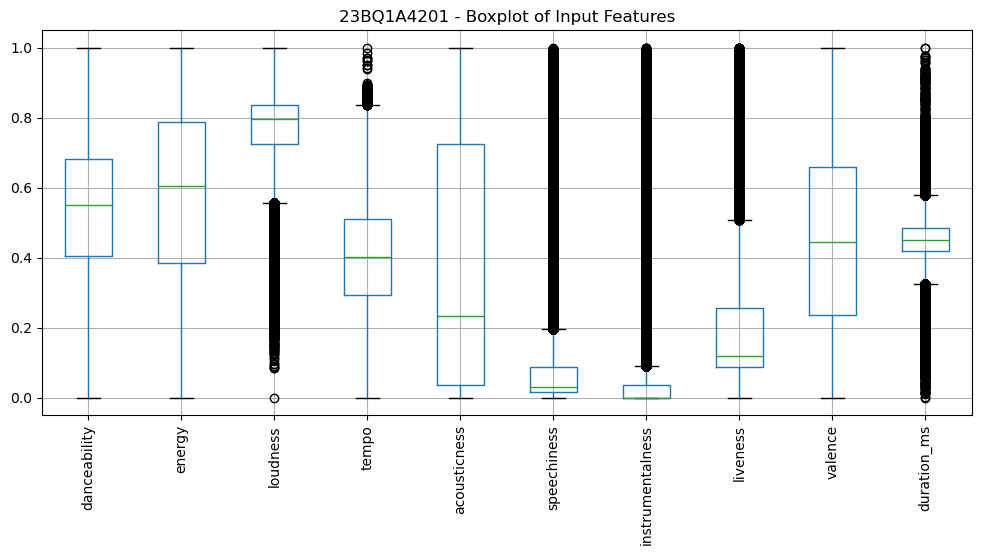

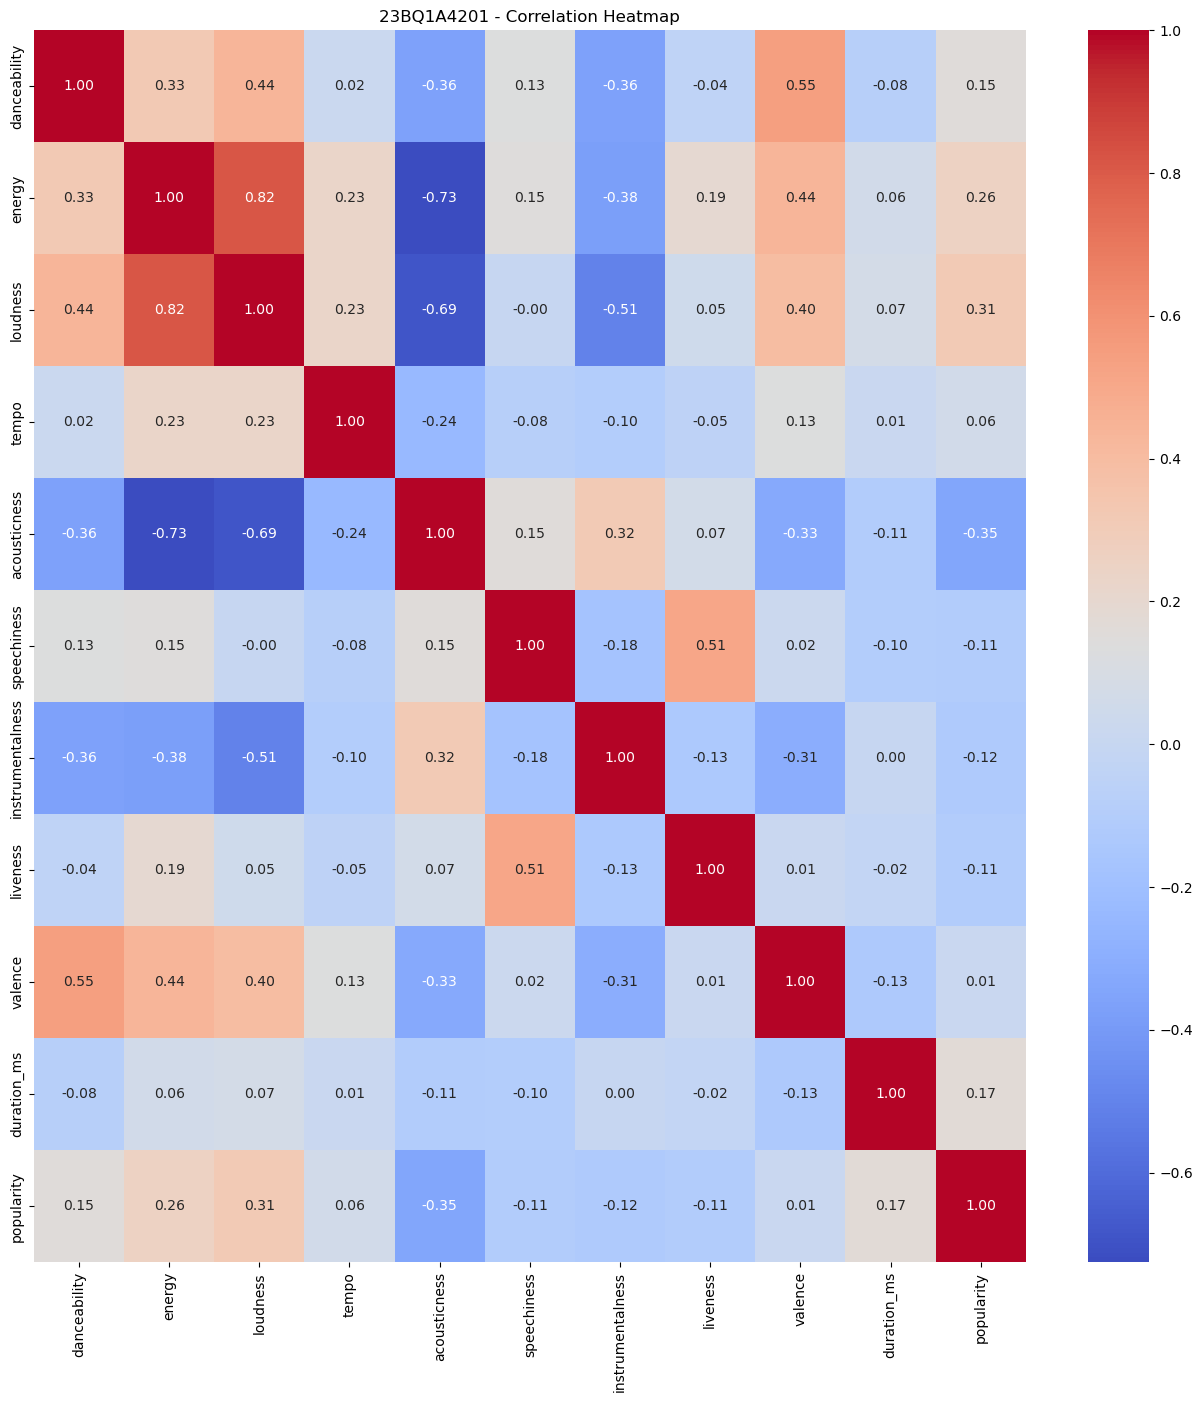

In [18]:
# Distribution of popularity
plt.figure(figsize=(6,4))
sns.histplot(spotify_df['popularity'], bins=30, kde=True)
plt.title("23BQ1A4201 - Distribution of Popularity")
plt.show()

# Boxplot of features
plt.figure(figsize=(12,5))
spotify_df[features_spotify].boxplot()
plt.xticks(rotation=90)
plt.title("23BQ1A4201 - Boxplot of Input Features")
plt.show()

# Correlation heatmap
plt.figure(figsize=(16,16))
sns.heatmap(spotify_df[features_spotify + [target_spotify]].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("23BQ1A4201 - Correlation Heatmap")
plt.show()

In [24]:
# split the dataset into training and testing
from sklearn.model_selection import train_test_split
X = spotify_df[features_spotify]
y = spotify_df[target_spotify]
print("The shape of the input features is: ", X.shape)
print("The shape of the target variable is: ", y.shape)
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
print("The shape of the training set is: ", X_train.shape)
print("The shape of the testing set is: ", X_test.shape)
print("The shape of the target variable in the training set is: ", y_train.shape)

The shape of the input features is:  (232725, 50)
The shape of the target variable is:  (232725,)
The shape of the training set is:  (186180, 50)
The shape of the testing set is:  (46545, 50)
The shape of the target variable in the training set is:  (186180,)


In [25]:
# Build the model
spotify_model = Sequential([
    Input(shape=(len(features_spotify),)),  # Input layer

    Dense(256, activation='relu'),          # Layer 1
    Dropout(0.2),                           # Dropout for regularization
    Dense(128, activation='relu'),          # Layer 2
    Dropout(0.2),
    Dense(64, activation='relu'),           # Layer 3
    Dropout(0.2),
    Dense(32, activation='relu'),           # Layer 4

    Dense(1, activation='linear')           # Output layer (linear for regression)
])

# Model summary
spotify_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,321 (220.00 KB)

 Trainable params: 56,321 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
spotify_model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Smaller learning rate for stability
    loss=tf.keras.losses.Huber(),  # More robust to outliers (reduces heteroscedastic impact)
    metrics=['mae']
)

print("Model compiled successfully!")

Model compiled successfully!


In [27]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history_s = spotify_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

print("Training complete!")

print("\nTraining Complete!")
print(f"Stopped at epoch: {len(history_s.history['loss'])}")
print(f"Best validation loss: {min(history_s.history['val_loss']):.4f}")
print(f"Best validation MAE: {min(history_s.history['val_mae']):.4f}")

Epoch 1/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0134 - mae: 0.1086 - val_loss: 0.0128 - val_mae: 0.1415
Epoch 2/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0064 - mae: 0.0706 - val_loss: 0.0082 - val_mae: 0.1007
Epoch 3/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0057 - mae: 0.0628 - val_loss: 0.0068 - val_mae: 0.0846
Epoch 4/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0055 - mae: 0.0599 - val_loss: 0.0068 - val_mae: 0.0839
Epoch 5/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0054 - mae: 0.0587 - val_loss: 0.0059 - val_mae: 0.0705
Epoch 6/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0054 - mae: 0.0582 - val_loss: 0.0057 - val_mae: 0.0677
Epoch 7/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0053 - mae: 0.0577 - val_loss: 0.0059 - val_mae: 0.0712
Epoch 8/200
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0053 - mae: 0.0573 - val_loss: 0.0055 - val_mae: 0.0627
Epoch 9/200
1164/1164 ━━━━━━━━━━

In [28]:
# Predictions
y_pred = spotify_model.predict(X_test)

# Metrics (normalized scale)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE (normalized) =====")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Inverse-transform predictions to original popularity scale (undo scaler and log1p)
y_test_orig = np.expm1(scaler_y.inverse_transform(y_test.values.reshape(-1,1)))
y_pred_orig = np.expm1(scaler_y.inverse_transform(y_pred))

# Metrics on original scale
mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mse_orig)
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
r2_orig = r2_score(y_test_orig, y_pred_orig)

print("\n===== MODEL PERFORMANCE (original scale) =====")
print(f"MSE: {mse_orig:.4f}")
print(f"RMSE: {rmse_orig:.4f}")
print(f"MAE: {mae_orig:.4f}")
print(f"R² Score: {r2_orig:.4f}")

1455/1455 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step

===== MODEL PERFORMANCE (normalized) =====
MSE: 0.0104
RMSE: 0.1019
MAE: 0.0556
R² Score: 0.6732

===== MODEL PERFORMANCE (original scale) =====
MSE: 95.8091
RMSE: 9.7882
MAE: 7.1936
R² Score: 0.7123


In [29]:
import pandas as pd
# Comparison Table
comparison_df = pd.DataFrame({
    "Actual_Popularity": y_test_orig.flatten(),
    "Predicted_Popularity": y_pred_orig.flatten()
})

print("\nSample Predictions:")
print(comparison_df.head(10))


Sample Predictions:
   Actual_Popularity  Predicted_Popularity
0               45.0             44.765530
1               25.0             32.557281
2               19.0             33.763939
3               29.0             36.228371
4               17.0             21.577393
5               16.0              1.600438
6               63.0             65.355865
7               51.0             58.264175
8               41.0             46.240578
9               65.0             46.515099


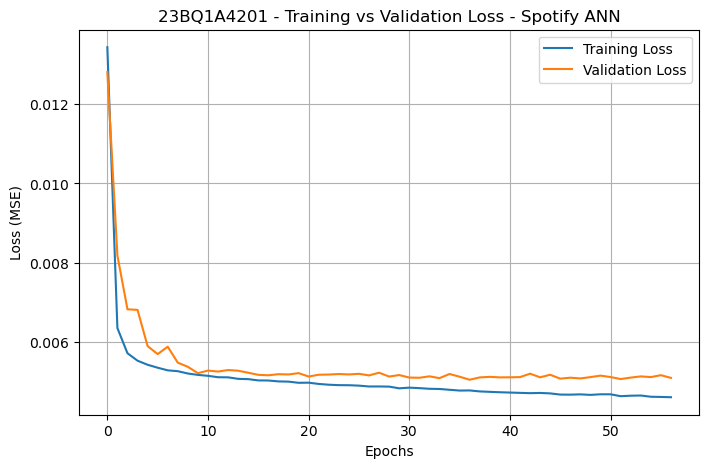

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_s.history['loss'], label='Training Loss')
plt.plot(history_s.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("23BQ1A4201 - Training vs Validation Loss - Spotify ANN")
plt.legend()
plt.grid(True)
plt.show()


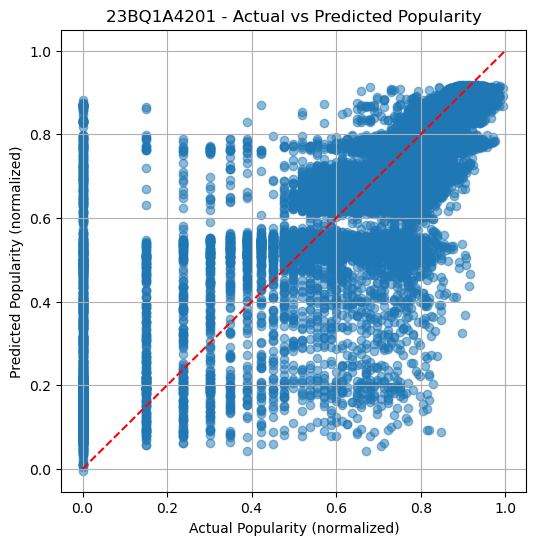

In [31]:
# Plot Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,1], [0,1], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual Popularity (normalized)")
plt.ylabel("Predicted Popularity (normalized)")
plt.title("23BQ1A4201 - Actual vs Predicted Popularity")
plt.grid(True)
plt.show()

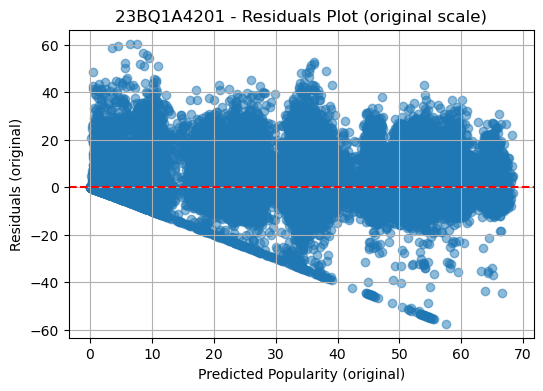

In [32]:
# Residuals plot
# Residuals plot on original scale
residuals_orig = y_test_orig.flatten() - y_pred_orig.flatten()
plt.figure(figsize=(6,4))
plt.scatter(y_pred_orig, residuals_orig, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Popularity (original)")
plt.ylabel("Residuals (original)")
plt.title("23BQ1A4201 - Residuals Plot (original scale)")
plt.grid(True)
plt.show()
